***** FASE 3 VISUALIZACIÓN *****

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df_all_limpi = pd.read_csv("files/df_all_limpi.csv")

Pregunta 1 ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

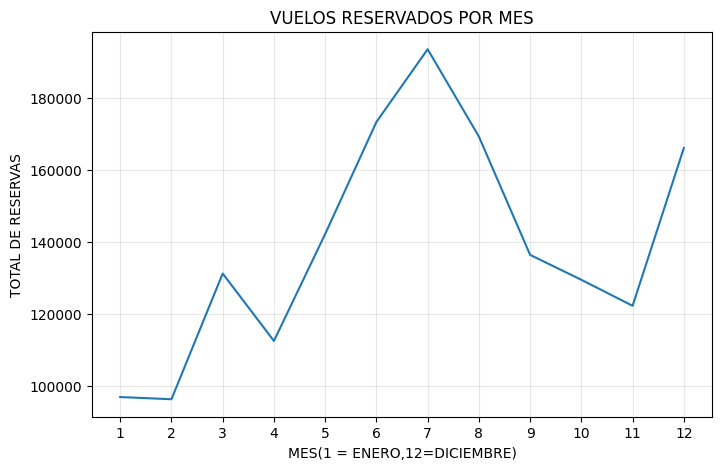

In [31]:
plt.figure(figsize=(8, 5))
v_mensuales = df_all_limpi.groupby("Month")["Flights Booked"].sum()
sns.lineplot( x=v_mensuales.index, y=v_mensuales.values)
plt.title("VUELOS RESERVADOS POR MES")
plt.xlabel("MES(1 = ENERO,12=DICIEMBRE)")
plt.ylabel ("TOTAL DE RESERVAS")
plt.xticks(range(1,13))# para que salgan todos los numeros
plt.grid (True, alpha =0.3)
plt.show()


Hallazgos:
* Los viajes no son todo el año igual
* En verano (julio y agosto )son cuando los clientees reservan mas vuelos 
* Diciembre tambien se ve un aumentos de reservas.

Pregunta 2 ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

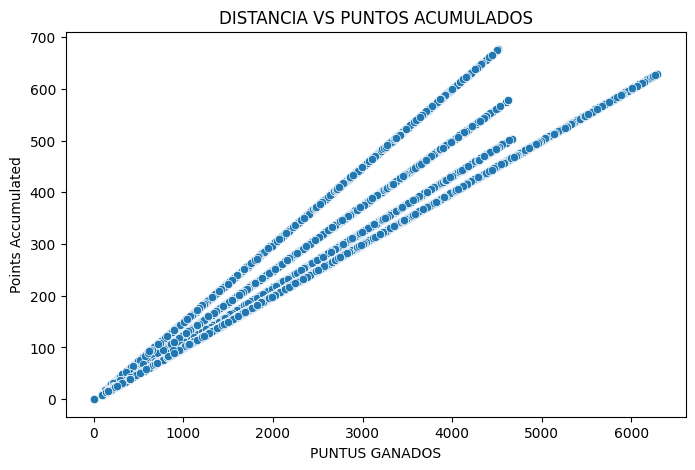

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data= df_all_limpi, x= "Distance", y= "Points Accumulated" )
plt.title("DISTANCIA VS PUNTOS ACUMULADOS")
plt.xlabel("PUNTUS GANADOS")
plt.show()

HALLAZGO:
* Los puntos acumulados y la distancia de los vuelos estan totalmente relacionados , entre mas lejos viajen mas puntos acumulan.

Pregunta 3 0. ¿Cuál es la distribución de los clientes por provincia o estado?

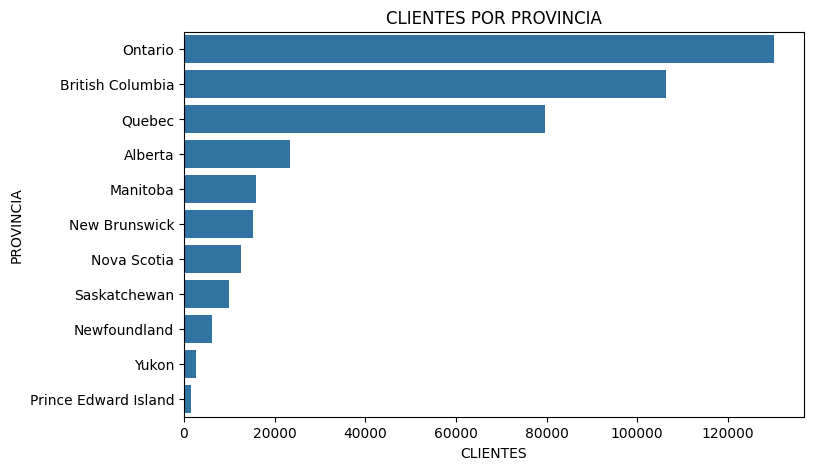

In [22]:
plt.figure(figsize=(8, 5))
orden_p = df_all_limpi["Province"].value_counts().index
sns.countplot(data = df_all_limpi, y= "Province", order = orden_p)
plt.title("CLIENTES POR PROVINCIA")
plt.xlabel("CLIENTES")
plt.ylabel("PROVINCIA")
plt.show()

HALLAZGOS:
* Muestra un concentracion masiva en Ontario , British y Quebec superando los 10 mil clientes
* Ontario es el que mas destaca con mas de 12 mil clientes
Yukon y Prince Edward practicamente casi no tienen clientes.

Pregunta 4 ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

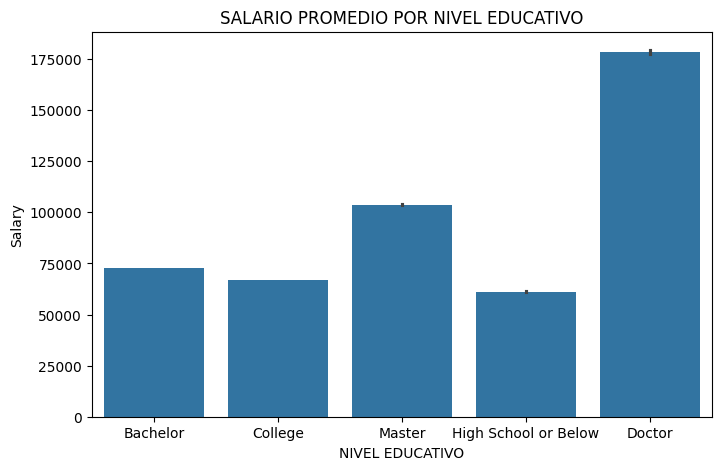

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data= df_all_limpi, x= "Education", y= "Salary")
plt.title("SALARIO PROMEDIO POR NIVEL EDUCATIVO")
plt.xlabel("NIVEL EDUCATIVO")
plt.show()

Hallazgos:
* Los clientes con nivel de doctor tienen el salario mas alto con diferencia de los demas acercandose a los 180 000
* Según aumenta nivel educativo va aumentando el suledo 
* Bachelor y college son muy similares, ya que imputamos con los salarios estimados para college 
* High school tiene el salario mas bajo 


Pregunta 5 3. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

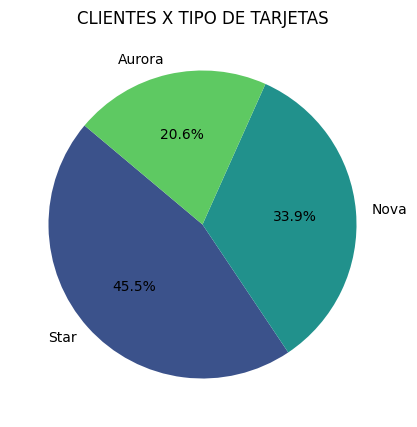

In [25]:
data_pie = df_all_limpi["Loyalty Card"].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(data_pie, 
        labels = data_pie.index,
        autopct = "%1.1f%%", # Esto pone el porcentaje con un decimal 
        startangle =140, #gira el grafico para que se vea mejor  
        colors= sns.color_palette("viridis",len(data_pie)))
plt.title("CLIENTES X TIPO DE TARJETAS")

plt.show()

HALLAZGOS :
* 45.5% pertenecen a la tarjeta star ( es el nivel mas bajo)
* 33.9% pertenecen a la tarjeta Nova que es un nivel intermedio 
* 20.6% pertenecen a la tarjeta Aurora que indica que es un nivel mas exclusivo

Pregunta 6 4. ¿Cómo se distribuyen los clientes según su estado civil y género?

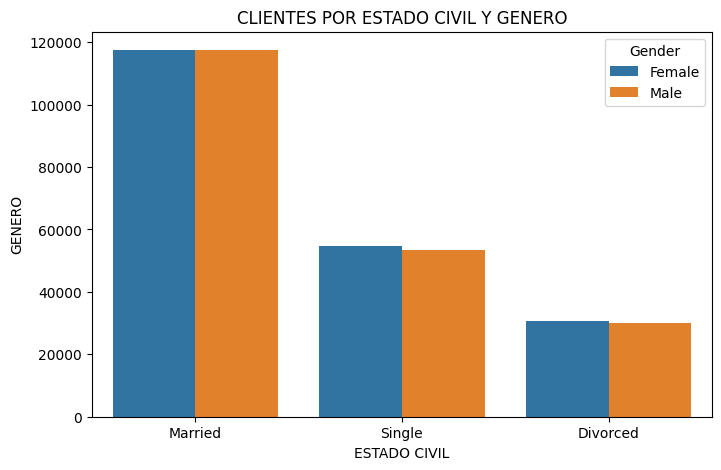

In [26]:
plt.figure(figsize=(8, 5))
orden_p = df_all_limpi["Province"].value_counts().index
sns.countplot(data = df_all_limpi, x= "Marital Status", hue = "Gender")
plt.title("CLIENTES POR ESTADO CIVIL Y GENERO")
plt.xlabel("ESTADO CIVIL")
plt.ylabel("GENERO")
plt.show()

HALLAZGO:
* Es mayor el numero de clientes casados frente a solteros y divorciados
* Hay casi la misma cantidad de hombres que de mujeres en cada grupo
* los divorciados son los que menos viajan ya que es la menor cantidad de clietnes

***** FASE 4 ******

Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo
Utilizando un conjunto de datos que hemos compartido, se busca evaluar si existen diferencias
significativas en el número de vuelos reservados según el nivel educativo de los clientes. Para ello, los
pasos que deberás seguir son:
-. Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes:
'Flights Booked' y 'Education'.
/. Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas
básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada
grupo.

In [ ]:
df_educacion_vuelos = df_all_limpi[["Education","Flights Booked"]] # hago una tabla mas pequeña 

In [ ]:
df_v_dif = df_educacion_vuelos.groupby("Education")["Flights Booked"].agg(["mean","std","count","max", "min"]) # agrupo por nivel de estudios y de eso grupos saque el numero de vuelos 
#utilizo .agg para poder calcular todoas las medidas al mismo timepo
df_v_dif

,mean,std,count,max,min
Education,,,,,
Bachelor,4.110288,5.221671,252567,21,0
College,4.169744,5.246040,102260,21,0
Doctor,4.175512,5.256971,17731,21,0
High School or Below,4.176209,5.239267,18915,21,0
Master,4.200700,5.213956,12287,21,0


Hallazgos:
* Todos viajan sen la media casi igual 
*  el maximo de vuelos es de 21 para todos los niveles
* La desviacion estandar tambien es muy similar en todos los niveles de educacion 
* Bachelor y College son los que mas reservan vuelos y no necesariamente son los que mas ganan

CONCLUSIONES

 El negocio es muy estacional.Hay picos de ventas muy claros en verano (julio) y en invierno (diciembre). 

 El sistema de recompensas funciona de forma justa y exacta, ya que los puntos suben siempre en proporción a la distancia volada. Además, la tarjeta Star es la base más grande de clientes, por lo que es el principal de programa de lealtad.

En resumen,los que mas viajan  pertenecen a  familias de clase media-alta que se situan en las provincias grandes, con viajes concentrados en periodos vacacionales."